# End-to-End ML Playground - Data Exploration

This notebook demonstrates data exploration and model training workflows using the playground datasets.

## 1. Setup and Imports

Load all required libraries for data analysis, visualization, and machine learning modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Classification Dataset

Load the sample classification dataset from the data folder and examine its basic structure.

In [2]:
# Load the sample classification dataset
df = pd.read_csv('../data/raw/sample_classification.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (30, 6)

First 5 rows:


,age,income,credit_score,loan_amount,tenure_months,target
0,24,42000,610,14000,24,0
1,29,52000,680,12000,36,1
2,35,61000,720,15000,48,1
3,41,58000,650,20000,60,0
4,27,47000,640,10000,24,0


**Dataset Info:**
- **Shape:** Number of samples × number of features
- **Columns:** Feature names and data types
- **Target:** Binary classification (0 or 1)

## 3. Exploratory Data Analysis (EDA)

Analyze the dataset for missing values, data types, and target class distribution to understand data quality and balance.

In [3]:
# Display basic statistics
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            30 non-null     int64
 1   income         30 non-null     int64
 2   credit_score   30 non-null     int64
 3   loan_amount    30 non-null     int64
 4   tenure_months  30 non-null     int64
 5   target         30 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB
None

Statistical Summary:


,age,income,credit_score,loan_amount,tenure_months,target
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,35.800000,63066.666667,703.000000,17200.000000,45.200000,0.600000
std,7.508156,14347.734011,61.316027,4141.047677,15.336232,0.498273
min,24.000000,41000.000000,600.000000,10000.000000,24.000000,0.000000
25%,29.250000,52250.000000,656.250000,14125.000000,36.000000,0.000000
50%,35.000000,61500.000000,697.500000,16250.000000,48.000000,1.000000
75%,41.750000,72500.000000,742.500000,20375.000000,60.000000,1.000000
max,50.000000,90000.000000,810.000000,25000.000000,72.000000,1.000000


**Key Observations:**
- Check for data imbalances (unequal class distribution)
- Look for missing values that may affect model training
- Identify outliers or unusual patterns in numerical features

In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df['target'].value_counts())

Missing values:
age              0
income           0
credit_score     0
loan_amount      0
tenure_months    0
target           0
dtype: int64

Target distribution:
target
1    18
0    12
Name: count, dtype: int64


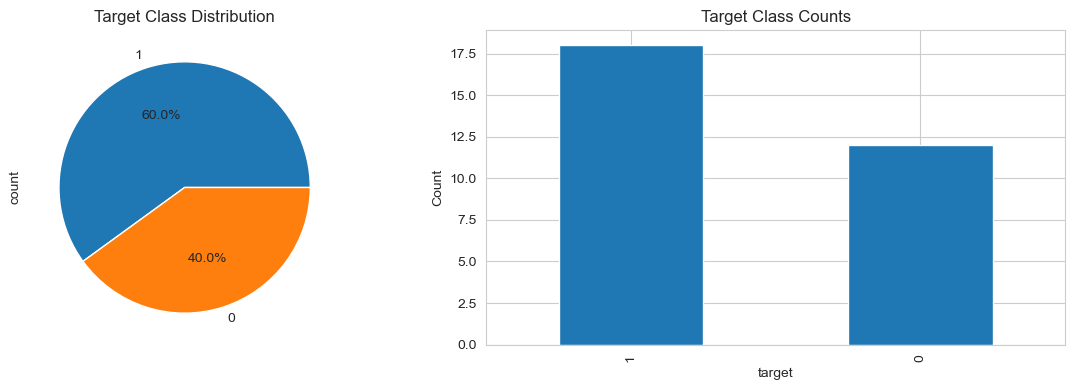

In [5]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Target Class Distribution')

# Bar chart
df['target'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Target Class Counts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Feature Analysis

Examine feature relationships and distributions across target classes to identify patterns and multicollinearity.

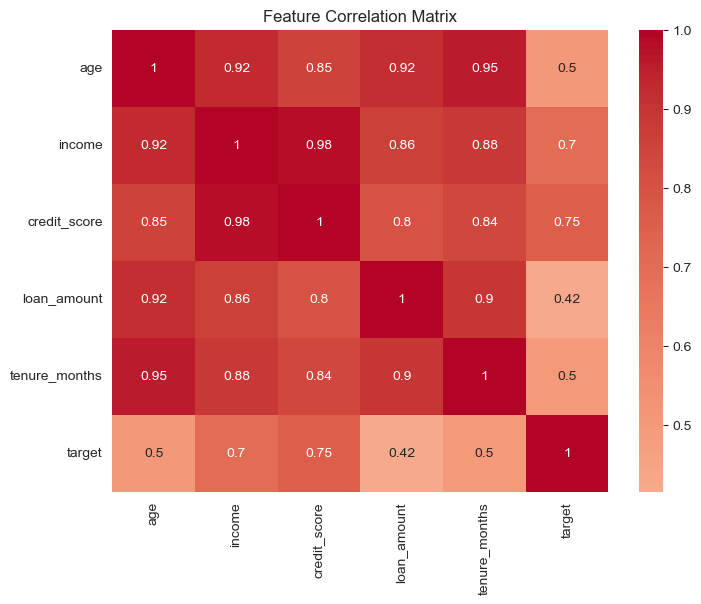

In [6]:
# Correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

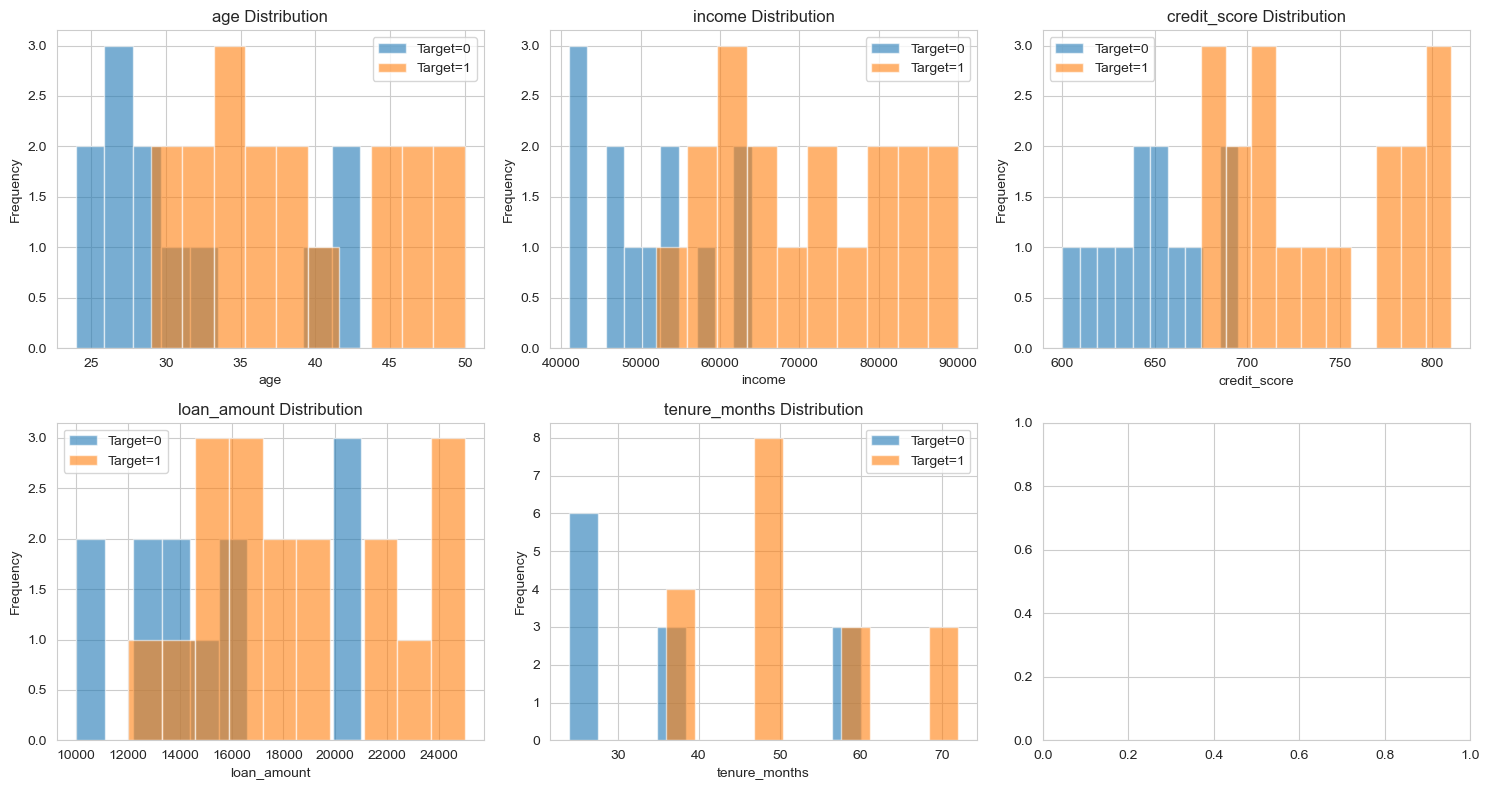

In [7]:
# Feature distributions by target class
features = [col for col in df.columns if col != 'target']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(features):
    for target_val in df['target'].unique():
        subset = df[df['target'] == target_val][feature]
        axes[idx].hist(subset, alpha=0.6, label=f'Target={target_val}')
    axes[idx].set_title(f'{feature} Distribution')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 5. Model Training and Comparison

Prepare data (split, scale) and train two classification models: Logistic Regression and Random Forest. Compare their performance on training and test sets to detect overfitting.

In [8]:
# Prepare data for modeling
X = df.drop(columns=['target']).astype(float)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 24
Test set size: 6


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why Feature Scaling?**

Standardization (scaling) normalizes features to have mean=0 and std=1. This is important for:
- **Logistic Regression:** Distance-based optimization (improves convergence)
- **Prevents feature dominance:** Large-range features don't overwhelm small-range features
- **Note:** Random Forest doesn't require scaling (tree-based models are scale-invariant)

In [10]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_train_acc = lr_model.score(X_train_scaled, y_train)
lr_test_acc = lr_model.score(X_test_scaled, y_test)

print(f"Logistic Regression:")
print(f"  Training Accuracy: {lr_train_acc:.4f}")
print(f"  Test Accuracy: {lr_test_acc:.4f}")
print(f"  Overfitting Gap: {lr_train_acc - lr_test_acc:.4f}")

Logistic Regression:
  Training Accuracy: 0.9583
  Test Accuracy: 1.0000
  Overfitting Gap: -0.0417


In [11]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = rf_model.score(X_test, y_test)

print(f"Random Forest:")
print(f"  Training Accuracy: {rf_train_acc:.4f}")
print(f"  Test Accuracy: {rf_test_acc:.4f}")
print(f"  Overfitting Gap: {rf_train_acc - rf_test_acc:.4f}")

Random Forest:
  Training Accuracy: 1.0000
  Test Accuracy: 1.0000
  Overfitting Gap: 0.0000


## 6. Model Evaluation

Generate confusion matrices and detailed classification reports (precision, recall, F1) for both models to assess their prediction quality.

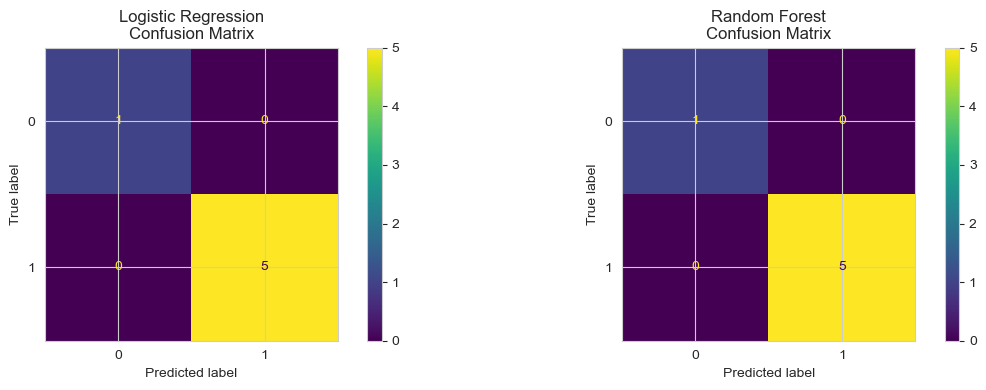

In [12]:
# Confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
lr_pred = lr_model.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')

# Random Forest
rf_pred = rf_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix')

plt.tight_layout()
plt.show()

**Interpreting Confusion Matrices:**
- **True Positives (TP):** Correctly predicted positive class
- **True Negatives (TN):** Correctly predicted negative class
- **False Positives (FP):** Incorrectly predicted as positive (Type I error)
- **False Negatives (FN):** Incorrectly predicted as negative (Type II error)

In [13]:
# Classification reports
print("=" * 50)
print("LOGISTIC REGRESSION REPORT")
print("=" * 50)
print(classification_report(y_test, lr_pred))

print("\n" + "=" * 50)
print("RANDOM FOREST REPORT")
print("=" * 50)
print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



## 7. Feature Importance (Random Forest)

Extract and visualize feature importance scores from the Random Forest model to understand which features drive predictions.

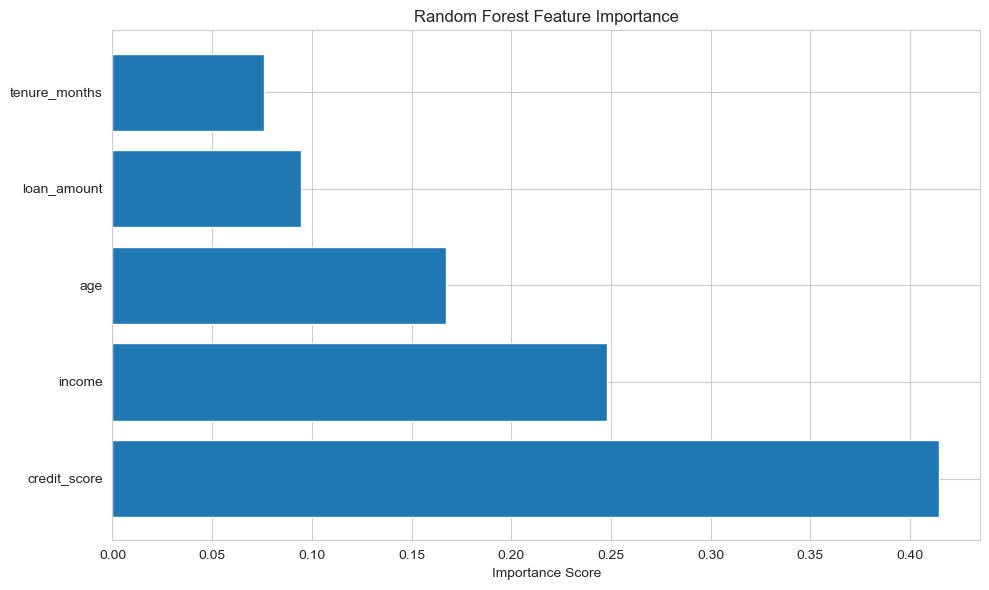

         feature  importance
2   credit_score    0.414322
1         income    0.247856
0            age    0.167378
3    loan_amount    0.094479
4  tenure_months    0.075965


In [14]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print(feature_importance)

**Feature Importance Insight:**

Random Forest ranks features by how much they reduce impurity (Gini) across all trees. Higher scores = more influential features for making predictions.

This helps with:
- Feature selection: Drop low-importance features
- Model interpretation: Understand what drives predictions
- Domain validation: Check if important features make business sense

## 8. Model Comparison Summary

Create a comprehensive side-by-side comparison of model performance metrics and visualizations to determine the best model for this dataset.


Model Comparison:
              Model  Train Accuracy  Test Accuracy  Overfitting Gap
Logistic Regression        0.958333            1.0        -0.041667
      Random Forest        1.000000            1.0         0.000000


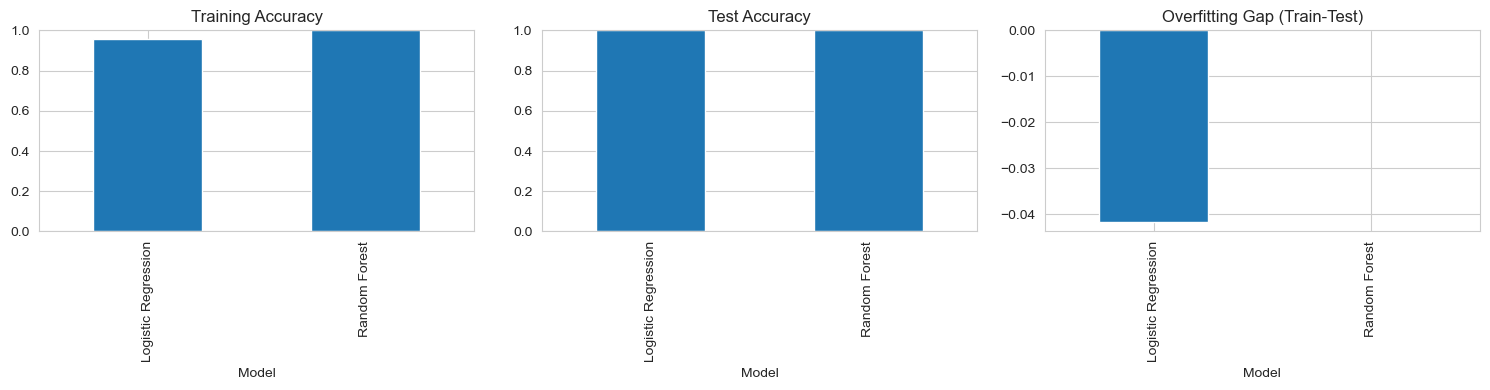

In [15]:
# Summary comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [lr_train_acc, rf_train_acc],
    'Test Accuracy': [lr_test_acc, rf_test_acc],
    'Overfitting Gap': [lr_train_acc - lr_test_acc, rf_train_acc - rf_test_acc]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparison.plot(x='Model', y='Train Accuracy', kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Training Accuracy')
axes[0].set_ylim([0, 1])

comparison.plot(x='Model', y='Test Accuracy', kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Test Accuracy')
axes[1].set_ylim([0, 1])

comparison.plot(x='Model', y='Overfitting Gap', kind='bar', ax=axes[2], legend=False)
axes[2].set_title('Overfitting Gap (Train-Test)')

plt.tight_layout()
plt.show()